# Scaling Laws

During this laboratory we will explore scaling laws, an important part of understanding large models. We will try to replicate some of the results of Training Compute-Optimal Large Language Models (https://arxiv.org/abs/2203.15556). You may find the [slides from the last lecture](https://docs.google.com/presentation/d/1pAeSSmt6jaebXuSI7nJf3EKj2nzldTWlArFkNogtZLs/edit#slide=id.p) helpful.

As the authors of the original paper did not release details of all experiments used to produce the final fit, we will use the data extracted from the plots on this paper by the authors of Chinchilla Scaling: A Replication Attempt (https://arxiv.org/abs/2404.10102). They released their analysis under a github repository (https://github.com/epoch-research/analyzing-chinchilla).

Let's start by loading the data.

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from itertools import product
from tqdm.notebook import tqdm

In [2]:
!git clone https://github.com/epoch-research/analyzing-chinchilla

Cloning into 'analyzing-chinchilla'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 30 (delta 7), reused 21 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 2.26 MiB | 27.61 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [3]:
data = pd.read_csv('analyzing-chinchilla/data/svg_extracted_data.csv')

## Exercise 1: Understanding the problem

Take a look into the [Scaling Laws paper](https://arxiv.org/abs/2203.15556) by Hoffmann et al. Read the introduction. Find answers to the following questions/problems in the paper:
  

1.   What is the main research question authors are investigating?
2.   Briefly explain the method taken in Approach 1 (Sec. 3.1).
3.   Briefly explain the method taken in Approach 2 (Sec. 3.2).
4.   Briefly explain the method taken in Approach 3 (Sec 3.3).

Can you identify any advantages or disadvantages of Approach 3 compared to the previous ones?

## Student's answer

1. *What is the main research question authors are investigating?*

    A: Citation: *Given a fixed FLOPs budget, how should one trade-off model
    size and the number of training tokens?* (for LLM architecture). Basically paper tries to find the optimal ratio between data (tokens in this case) to number of parameters of the model, such data total compute power is less or equal to given number. Their results differ than Kaplan et al. results - here results suggests we should balance number of parameters and number of tokens equally, so models should be smaller than in case of Kaplan et. al. and trained longer. Note that we strictly focus only on LLM architecture.
$$
    N_{\text{opt}}(C), D_{\text{opt}}(C) = argmin_{N, D: \text{FLOPS}(N,D)\leq C} L(N,D)
$$

2.  *Briefly explain the method taken in Approach 1 (Sec. 3.1).*
    
    A: We fix number of parameters N (for a given set of $A$ sizes N, min(A) = 70M, max(A) = 10B), then check few runs of training with different number of data for each number of parameters. We try to get the optimal amount of tokens for given number of parameters. To be more precise:
    
    - 4 runs
    - learning rate changes (10 times smaller for 16 times more tokens?)
    - interpolate and smooth loss curve for each run
    - we compute which run had the best results for each FLOP
    - we fit power law to results

3.  *Briefly explain the method taken in Approach 2 (Sec. 3.2).*

    A: Approach *IsoFLOP profiles*, we fix set of FLOPS (e.g. from $6 * 10^{18}$ up to $3 * 10^{21}$). For each number of FLOPS we train few number of parameters. We train these models and take the last loss as the result of trained model. We take the smallest loss for each number of FLOPS. We fit parabola for these minimal losses.

4. *Briefly explain the method taken in Approach 3 (Sec 3.3).*

    A: Approach *Fitting a parametric loss function*, they propose a loss function of form
    $$L(N,D) = E + \frac{A}{N^a} + \frac{B}{D^b}$$
    where E is entropy of natural text.
    They want to find best fitting parameters $A,a,B,b$ for given losses.
    They look at end losses of each experiment run in approach 1 and 2.
    They want to fit best function loss to these experiments. To define how good is fit they define loss function over these observations (experiments) and parameters (A,a,B,b) of form of sum of Hubert losses. Then after finding parameters they compute optimal N and D for each FLOPS, assuming 6ND=C (empirically chosen).

*Can you identify any advantages or disadvantages of Approach 3 compared to the previous ones?*

A: Third approach uses some harder theory, it computes best prediction for loss function in given family of functions, other do not (**first advantage - we got some loss estimate**). In particular each experiment can be invalid, maybe their is some noise in experiments. In this case we should treat experiments results as some kind of defined model + noise. To find this model of loss we use ML methods. This can be more accurate than looking at each experiments and fit parameters N and D by e.g. interpolation, as there might be outliers in experiments (**second advantage**). Problem is that we might have chosen terrible family of loss functions approximating true statistics (**disadvantage**).

## Exercise 2: Understanding the data

In this exercise we will examine the data from experiments and make sure they are complete. You may find the function `num_to_readable` (from the cell below) helpful in printing the numbers in human readable format.

In [4]:
def num_to_readable(num):
    if 1e6 <= num < 1e9:
        return f"{num/1e6:.2f}M"
    elif 1e9 <= num < 1e12:
        return f"{num/1e9:.2f}B"
    elif 1e12 <= num < 1e15:
        return f"{num/1e12:.2f}T"
    elif num >= 1e15:
        return f"{num:.5e}"
    elif isinstance(num, float):
        return f"{num:.6}"
    else:
        return f"{num}"

1.   The downloaded data contain columns corresponding to training FLOPs $C$, and model size $N$. Please add a column with dataset size $D$ using a commonly used heuristic for calculating the training cost for Transformers:
$$C=6ND.$$


In [5]:
# Student's cell
print(data.columns)

Index(['x', 'y', 'color', 'Model Size', 'Training FLOP', 'hex_color', 'loss'], dtype='object')


In [6]:
data["Tokens"] = data["Training FLOP"] / (6 * data["Model Size"])
data

,x,y,color,Model Size,Training FLOP,hex_color,loss,Tokens
0,154.03592,140.63364,#faebdd,6.795600e+09,9.993853e+18,#faebdd,5.005582,2.451060e+08
1,151.60375,175.51709,#f8d1b8,2.979521e+09,9.227541e+18,#f8d1b8,4.665232,5.161647e+08
2,153.29233,180.65761,#f47a54,2.638631e+09,9.753047e+18,#f47a54,3.765563,6.160421e+08
3,152.88216,186.78615,#f47d57,2.282804e+09,9.622708e+18,#f47d57,3.793872,7.025502e+08
4,153.35068,192.24076,#ed503e,2.006673e+09,9.771731e+18,#ed503e,3.446995,8.116029e+08
...,...,...,...,...,...,...,...,...
240,302.37174,198.50406,#591e50,1.730547e+09,1.296639e+21,#591e50,2.286446,1.248775e+11
241,312.28760,186.78606,#531e4d,2.282809e+09,1.795036e+21,#531e4d,2.249076,1.310546e+11
242,319.95230,180.65752,#4e1d4b,2.638636e+09,2.308123e+21,#4e1d4b,2.222281,1.457902e+11
243,323.82795,175.51700,#4c1d4b,2.979528e+09,2.621011e+21,#4c1d4b,2.212313,1.466122e+11


2.   Examine the data: find the number of experiments, smallest and largest one (in terms of FLOPs), the range of model and dataset sizes.

In [7]:
print(f"Nr of experiments: {len(data)}")
print(f"Smallest FLOPS:", num_to_readable(data['Training FLOP'].min()))
print(f"Largest FLOPS: {num_to_readable(data['Training FLOP'].max())}")
print(f"Smallest model size: {num_to_readable(data['Model Size'].min())}")
print(f"Largest model size: {num_to_readable(data['Model Size'].max())}")
print(f"Smallest dataset size: {num_to_readable(data['Tokens'].min())}")
print(f"Largest dataset size: {num_to_readable(data['Tokens'].max())}")

Nr of experiments: 245
Smallest FLOPS: 1.39724e+18
Largest FLOPS: 1.29560e+22
Smallest model size: 57.33M
Largest model size: 16.18B
Smallest dataset size: 245.11M
Largest dataset size: 317.75B


3.   Let's try to get an idea of the scale of the experiments:

* Calculate the total amount of FLOPs (the sum) in all of them. Compare this value to the FLOPs used to train the main Chinchilla model (you can read the latter value from Figure 1 in the paper).
* According to the [data sheet](https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/a100/pdf/nvidia-a100-datasheet-us-nvidia-1758950-r4-web.pdf) of NVIDIA A100, it operates at 312 TFLOPs ($=312\cdot 10^{12}$) per second. Let's imagine we want to replicate the results of the paper by renting A100s in the cloud. Assuming MFU of 50% (that is, effectively our code runs on the GPU at 156 TFLOPs/s), estimate the number of GPU-hours that would be needed to run all of the experiments  in our table and their cost (A100 in the preemptible mode costs around $2/hour).

In [8]:
print(f"Total nr of FLOPs: {num_to_readable(data['Training FLOP'].sum())}")
print(f"Nr of FLOPS for training Chinchilla model: {num_to_readable(5.76e+23)} (by table 3, \n as it should be the same as Gopher,\n is almost the same as estimation 6ND and \n we do not have exactly the number on figure 1)")

Total nr of FLOPs: 1.05181e+23
Nr of FLOPS for training Chinchilla model: 5.76000e+23 (by table 3, 
 as it should be the same as Gopher,
 is almost the same as estimation 6ND and 
 we do not have exactly the number on figure 1)


In [26]:
N_FLOPS_PER_SEC = 312e12 * 0.5
nr_of_hours = data['Training FLOP'].sum() / N_FLOPS_PER_SEC / 3600
print(data['Training FLOP'].sum())

print(f"Nr of GPU hours: {nr_of_hours}, nr of days: {nr_of_hours/24}, nr of years: {nr_of_hours/24/365.25}")
print(f"Cost: {nr_of_hours*2}$")

1.051809089538968e+23
Nr of GPU hours: 187287.94329397578, nr of days: 7803.664303915658, nr of years: 21.365268456990165
Cost: 374575.88658795157$


## Exercise 3: Replicating Approach 2

In this exercise, we will replicate Approach 2: IsoFLOP profiles from the paper.

1. For each budget from the list in the cell below, find the experiments, where
$$|log(\text{experiment_budget})-log(\text{closest_budget_from_list})| < 0.2.$$
We will use only these experiments in the analysis in this exercise.

In [10]:
flop_budgets = [6e18, 1e19, 3e19, 6e19, 1e20, 3e20, 6e20, 1e21, 3e21]

In [11]:
def calculate_closest_budget(budget):
    closest_budget = min(flop_budgets, key=lambda x: abs(x - budget))
    return closest_budget

In [12]:
# data_filtered = data[np.abs(np.log(data['Training FLOP'].apply(calculate_closest_budget)) - np.log(data['Training FLOP'])) < 0.2]
# data_filtered["closest_budget"] = data_filtered['Training FLOP'].apply(calculate_closest_budget)
# data_filtered.head()
data_cpy = data.copy()
data_cpy["closest_budget"] = data_cpy['Training FLOP'].apply(calculate_closest_budget)
data_filtered = data_cpy[np.abs(np.log(data_cpy["closest_budget"]) - np.log(data_cpy["Training FLOP"])) < 0.2]
data_filtered

,x,y,color,Model Size,Training FLOP,hex_color,loss,Tokens,closest_budget
0,154.03592,140.63364,#faebdd,6.795600e+09,9.993853e+18,#faebdd,5.005582,2.451060e+08,1.000000e+19
1,151.60375,175.51709,#f8d1b8,2.979521e+09,9.227541e+18,#f8d1b8,4.665232,5.161647e+08,1.000000e+19
2,153.29233,180.65761,#f47a54,2.638631e+09,9.753047e+18,#f47a54,3.765563,6.160421e+08,1.000000e+19
3,152.88216,186.78615,#f47d57,2.282804e+09,9.622708e+18,#f47d57,3.793872,7.025502e+08,1.000000e+19
4,153.35068,192.24076,#ed503e,2.006673e+09,9.771731e+18,#ed503e,3.446995,8.116029e+08,1.000000e+19
...,...,...,...,...,...,...,...,...,...
231,293.75688,201.58295,#5e1f52,1.609083e+09,9.774574e+20,#5e1f52,2.314015,1.012437e+11,1.000000e+21
232,293.32536,206.59748,#611f53,1.429236e+09,9.637196e+20,#611f53,2.331417,1.123817e+11,1.000000e+21
233,293.64765,211.74199,#611f53,1.265596e+09,9.739615e+20,#611f53,2.331417,1.282613e+11,1.000000e+21
238,257.26564,230.29248,#751f58,8.163432e+08,2.953043e+20,#751f58,2.445913,6.029005e+10,3.000000e+20


2. For each budget group, fit a parabola in the log-log scale between number of parameters and loss (i.e. x scale is $log(params)$ and y scale is $log(loss)$, as in the plot from the paper pasted below). Find the minimum of each parabola - this is our estimated optimal model size for each budget group. Plot the points together with the fitted parabolas. Finally, list the estimated optimal number of parameters, training tokens, and corresponding token to parameter ratio for each budget group.

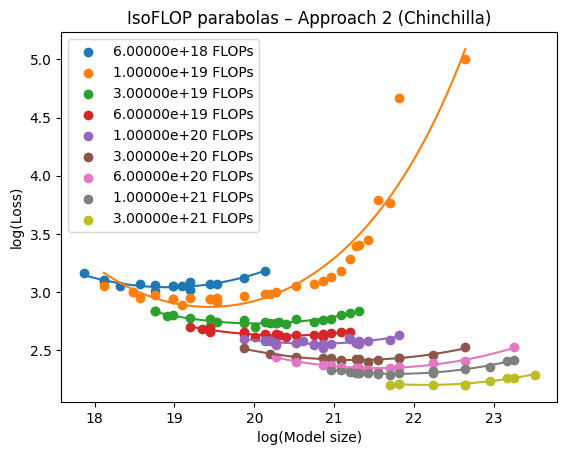

In [27]:
# Students solution
for budget in flop_budgets:
  group = data_filtered[data_filtered["closest_budget"] == budget]
  x = group["Model Size"].values
  y = group["loss"].values
  logx = np.log(x)
  logy = np.log(y)
  coefs = np.polyfit(logx, logy, 2)
  a,b,c = coefs
  # ax^2 + bx + c
  # log_opt_N = -b/(2*a)
  # opt_N = np.exp(log_opt_N)
  # log_opt_loss = a*log_opt_N**2 + b*log_opt_N + c
  # opt_loss = np.exp(log_opt_loss)
  # a (b^2/4a^2) -(b^2/2a) + c = b^2(1-2/2a)+c = -b^2/2a + c
  plt.scatter(logx, np.exp(logy), label=f"{num_to_readable(budget)} FLOPs")
  xs = np.linspace(min(logx), max(logx), 200)
  ys = a * xs**2 + b * xs + c
  ys = np.exp(ys)
  plt.plot(xs, ys)
plt.xlabel("log(Model size)")
plt.ylabel("log(Loss)")
plt.title("IsoFLOP parabolas – Approach 2 (Chinchilla)")
plt.legend()
plt.show()

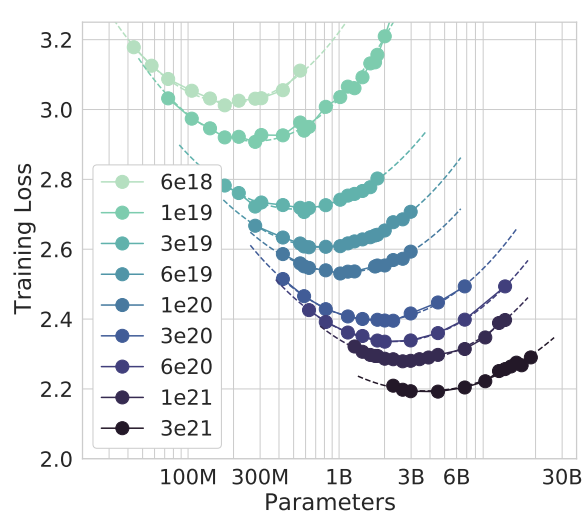

In [14]:
# TODO: plot

In [15]:
def fit_parabola_and_find_min(group):
    # TODO BEGIN
    x = group["Model Size"].values
    y = group["loss"].values
    logx = np.log(x)
    logy = np.log(y)
    coefs = np.polyfit(logx, logy, 2)
    a,b,c = coefs
    # ax^2 + bx + c
    log_opt_N = -b/(2*a)
    optimal_model_size = np.exp(log_opt_N)
    log_opt_loss = a*log_opt_N**2 + b*log_opt_N + c
    predicted_min_loss = np.exp(log_opt_loss)
    # TODO END

    # Return the results
    return pd.DataFrame({
        'budget_group': [group.name],
        'optimal_model_size': [optimal_model_size],
        'predicted_min_loss': [predicted_min_loss]
    })


In [16]:
# Apply the function to each budget_group
results = data_filtered.groupby('closest_budget').apply(fit_parabola_and_find_min) # STUDENTS note: had to change from budget_group to closest_budget

# Reset index to flatten the DataFrame
results = results.reset_index(drop=True)

/tmp/ipython-input-3682347824.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = data_filtered.groupby('closest_budget').apply(fit_parabola_and_find_min) # STUDENTS note: had to change from budget_group to closest_budget


In [17]:
results["token_param_ratio"] = (results['budget_group'] / (6*results["optimal_model_size"])) / results["optimal_model_size"]
results

,budget_group,optimal_model_size,predicted_min_loss,token_param_ratio
0,6.000000e+18,1.643204e+08,3.041776,37.035395
1,1.000000e+19,2.763381e+08,2.872944,21.825646
2,3.000000e+19,4.992376e+08,2.730810,20.061133
3,6.000000e+19,7.300898e+08,2.626848,18.760633
4,1.000000e+20,1.026432e+09,2.556528,15.819350
5,3.000000e+20,1.677062e+09,2.416597,17.777545
6,6.000000e+20,2.229523e+09,2.347281,20.117591
7,1.000000e+21,2.845610e+09,2.297781,20.582487
8,3.000000e+21,4.131841e+09,2.202439,29.287532


## Exercise 4: Replicating Approach 3

In this exercise we will replicate Approach 3 from the paper: Fitting the Parametric Loss Function. Implement the fitting and fit the final formula. You can find the description of the process in Section 3.3 and D.2 of the paper. Make sure to use a grid of initializations and simply choose the initialization of parameters that allows to minimize RMSE on the data.

In [25]:
N = torch.Tensor(data["Model Size"]).requires_grad_(False)
D = torch.Tensor(data["Tokens"]).requires_grad_(False)
L = torch.Tensor(data["loss"]).requires_grad_(False)
# Students code:
print(N.shape)
print(torch.arange(9))
a = torch.log(1+torch.arange(9)).reshape(3,3)
print(torch.logsumexp(a, dim=0))

torch.Size([245])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
tensor([2.1972, 2.4849, 2.7081])


In [19]:
def predict_loss(N, a, alpha, D, b, beta, e):
    return a / N**alpha + b / D**beta + e

In [20]:
def rmse(L, L_pred):
    return torch.sqrt(torch.mean((L - L_pred) ** 2))

In [91]:
def compute_scaling_law(N, a, alpha, D, b, beta, e, L, huber_delta):
    """
    params:
    N, a, alpha, D, b, beta, e: initial values for the parameters of the scaling law
    huber_delta: delta parameter for the Huber loss
    weight_decay: weight decay parameter for the L1 regularization
    """
    alpha = torch.Tensor([alpha]).requires_grad_(True)
    a = torch.Tensor([a]).requires_grad_(True)
    beta = torch.Tensor([beta]).requires_grad_(True)
    b = torch.Tensor([b]).requires_grad_(True)
    e = torch.Tensor([e]).requires_grad_(True)

    logN = torch.log(N)
    logD = torch.log(D)
    logL = torch.log(L)

    def objective(N, a, alpha, D, b, beta, e, L, delta):
        # TODO BEGIN
        # First version according to section 3.3:
        # L_pred = predict_loss(N, a, alpha, D, b, beta, e)
        # diff = torch.abs(torch.log(L_pred) - torch.log(L))
        # loss = torch.where(diff <= delta, 0.5*(diff**2), delta*(diff-0.5*delta)).sum()
        # minimizer sum = minimizer mean, but maybe mean has smaller losses, maybe better convergence?
        # Second version according to D2:
        fst = a - alpha * logN
        snd = b - beta * logD
        thd = e.expand_as(N)
        stacked = torch.stack([fst,snd,thd], dim=0)
        lse = torch.logsumexp(stacked,dim=0) # dim=?
        diff = torch.abs(lse - logL)
        # loss = torch.where(diff <= delta, 0.5*(diff*diff), delta*(diff-0.5*delta)).sum()
        loss = torch.nn.functional.huber_loss(lse, torch.log(L), reduction='sum', delta=huber_delta)
        # TODO END

        return loss


    def closure():
        lbfgs.zero_grad()
        loss = objective(N, a, alpha, D, b, beta, e, L, huber_delta)
        loss.backward()
        return loss

    lbfgs = optim.LBFGS([a, alpha, b, beta, e],
                        history_size=10000,
                        lr=0.1,
                        max_iter=100000,
                        line_search_fn="strong_wolfe")

    lbfgs.step(closure)

    # TODO BEGIN?
    # with torch.no_grad():
    #   A, alpha, B, beta, E = a.item(), alpha.item(), b.item(), beta.item(), e.item()
    with torch.no_grad():
        A = torch.exp(a).item()
        B = torch.exp(b).item()
        E = torch.exp(e).item()
        alpha = alpha.item()
        beta  = beta.item()
    # TODO END

    return A, alpha, B, beta, E

In [92]:
huber_deltas = [0.001]
alpha_inits = [0.5, 1.0, 1.5]
beta_inits = [0.5, 1.0, 1.5]
a_inits = [5., 10., 15.]
b_inits = [5., 10., 15.]
e_inits = [-0.5, 0., 0.5]

# fit the scaling law for all combinations...
results = []
counter = 0
for delta in huber_deltas:
  for alpha_init in alpha_inits:
    for beta_init in beta_inits:
      for a_init in a_inits:
        for b_init in b_inits:
          for e_init in e_inits:
            A, alpha, B, beta, E = compute_scaling_law(
                N, a_init, alpha_init, D, b_init, beta_init, e_init, L, huber_delta=delta
            )
            # if counter < 5:
            #   print(f"Combination {counter}")
            # if counter % 50 == 0 and counter > 5:
            #   print(f"Combination {counter}")
            # counter += 1
            score = rmse(L, predict_loss(N, A, alpha, D, B, beta, E)).item()
            results.append({
                "A": A,
                "alpha": alpha,
                "B": B,
                "beta": beta,
                "E": E,
                "train_score": score,
            })
df = pd.DataFrame(results)


In [93]:
df.sort_values("train_score")

,A,alpha,B,beta,E,train_score
6,1.503797e+02,0.275381,2.447956e+06,0.704464,1.886670,0.060995
20,4.077569e+03,0.467755,4.030122e+05,0.616867,2.081191,0.061702
101,4.108225e+03,0.468176,4.021438e+05,0.616751,2.081453,0.061718
100,4.209341e+03,0.469500,4.057356e+05,0.617194,2.082359,0.061738
99,4.252757e+03,0.470067,4.052228e+05,0.617129,2.082664,0.061757
...,...,...,...,...,...,...
237,3.269020e+06,1.499974,2.202646e+04,1.500000,2.614598,0.368398
223,1.484132e+02,1.500000,3.269017e+06,1.500000,2.614601,0.368398
232,2.202646e+04,1.500000,3.269017e+06,1.500000,2.614601,0.368398
207,3.269020e+06,1.499975,1.484132e+02,0.999999,2.614583,0.368400
